# benchmark_definitif.ipynb

In [1]:
# notebooks/benchmark_definitif.ipynb
# ─────────────────────────────────────────────────────────────
# CELLULE 1 — Setup
# ─────────────────────────────────────────────────────────────

import sys
from pathlib import Path
import warnings
import time
warnings.filterwarnings("ignore")

RACINE = Path("..").resolve()
if str(RACINE) not in sys.path:
    sys.path.insert(0, str(RACINE))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from elasticsearch import Elasticsearch
import psycopg2
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from dotenv import load_dotenv
import os

load_dotenv(RACINE / ".env")
print("Imports OK")

Imports OK


In [2]:
# ─────────────────────────────────────────────────────────────
# CELLULE 2 — Connexions
# ─────────────────────────────────────────────────────────────

es = Elasticsearch(
    f"http://{os.getenv('ELASTIC_HOST', 'localhost')}:"
    f"{os.getenv('ELASTIC_PORT', 9200)}"
)
assert es.ping(), "Elasticsearch inaccessible"

conn = psycopg2.connect(
    host     = os.getenv("POSTGRES_HOST", "localhost"),
    port     = int(os.getenv("POSTGRES_PORT", 5432)),
    dbname   = os.getenv("POSTGRES_DB", "job_market"),
    user     = os.getenv("POSTGRES_USER"),
    password = os.getenv("POSTGRES_PASSWORD"),
)
print("Connexions OK")

Connexions OK


In [4]:
# ─────────────────────────────────────────────────────────────
# CELLULE 3 — Chargement des données
# ─────────────────────────────────────────────────────────────

df_offres = pd.read_sql("""
    SELECT
        o.id,
        o.titre,
        o.description,
        STRING_AGG(DISTINCT c.competence, ' ') AS competences
    FROM offres o
    LEFT JOIN competences c ON c.offre_id = o.id
    GROUP BY o.id, o.titre, o.description
""", conn)

df_offres["texte"] = (
    df_offres["titre"].fillna("")       + " " +
    df_offres["titre"].fillna("")       + " " +
    df_offres["description"].fillna("") + " " +
    df_offres["competences"].fillna("")
)

# Ground truth
df_labels = pd.read_sql("""
    SELECT offre_id AS id, ml_keyword
    FROM ml_labels
""", conn)

keywords = df_labels["ml_keyword"].unique().tolist()

print(f"Offres    : {len(df_offres)}")
print(f"Labels    : {len(df_labels)}")
print(f"Keywords  : {len(keywords)}")

Offres    : 8592
Labels    : 15048
Keywords  : 47


In [5]:
# ─────────────────────────────────────────────────────────────
# CELLULE 4 — Métriques standard IR
# ─────────────────────────────────────────────────────────────

def precision_at_k(ids_retournes: list, ids_positifs: set, k: int) -> float:
    """
    Précision@K — parmi les K premiers résultats, combien sont pertinents ?

    C'est la métrique la plus intuitive :
    si P@10 = 0.7, 7 des 10 premiers résultats sont pertinents.
    """
    if not ids_retournes or k == 0:
        return 0.0
    top_k   = ids_retournes[:k]
    nb_vrais = sum(1 for id_ in top_k if id_ in ids_positifs)
    return nb_vrais / k


def reciprocal_rank(ids_retournes: list, ids_positifs: set) -> float:
    """
    Reciprocal Rank — inverse du rang du premier résultat pertinent.

    RR = 1    si le 1er résultat est pertinent
    RR = 0.5  si le 2ème est pertinent
    RR = 0.25 si le 4ème est pertinent
    RR = 0    si aucun résultat n'est pertinent

    MRR = moyenne des RR sur tous les keywords.
    """
    for rang, id_ in enumerate(ids_retournes, start=1):
        if id_ in ids_positifs:
            return 1.0 / rang
    return 0.0


def ndcg_at_k(ids_retournes: list, ids_positifs: set, k: int) -> float:
    """
    NDCG@K — Normalized Discounted Cumulative Gain.

    Récompense les résultats pertinents en tête de liste.
    Un résultat pertinent en position 1 vaut plus qu'en position 10.

    NDCG = 1.0 → classement parfait (tous les pertinents en premier)
    NDCG = 0.0 → aucun pertinent dans le top-K

    C'est la métrique la plus complète pour un moteur de recherche.
    """
    top_k = ids_retournes[:k]

    # Gain cumulé actualisé — les premières positions valent plus
    dcg = sum(
        1.0 / np.log2(rang + 1)
        for rang, id_ in enumerate(top_k, start=1)
        if id_ in ids_positifs
    )

    # Gain idéal — tous les pertinents en premier
    nb_pertinents_ideaux = min(len(ids_positifs), k)
    idcg = sum(
        1.0 / np.log2(rang + 1)
        for rang in range(1, nb_pertinents_ideaux + 1)
    )

    return dcg / idcg if idcg > 0 else 0.0


print("Métriques IR définies.")
print("""
Rappel des métriques :
  Précision@K  → qualité des K premiers résultats
  MRR          → rapidité à trouver le premier résultat pertinent
  NDCG@K       → qualité du classement global dans le top-K
""")

Métriques IR définies.

Rappel des métriques :
  Précision@K  → qualité des K premiers résultats
  MRR          → rapidité à trouver le premier résultat pertinent
  NDCG@K       → qualité du classement global dans le top-K



In [6]:
# ─────────────────────────────────────────────────────────────
# CELLULE 5 — Initialisation des moteurs
# ─────────────────────────────────────────────────────────────

print("Initialisation...\n")

# TF-IDF
print("1/4 TF-IDF...")
tfidf   = TfidfVectorizer(max_features=10000, ngram_range=(1,2), sublinear_tf=True)
X_tfidf = tfidf.fit_transform(df_offres["texte"])
print(f"    Matrice {X_tfidf.shape}")

# BM25
print("2/4 BM25...")
corpus_bm25 = [t.lower().split() for t in df_offres["texte"]]
bm25        = BM25Okapi(corpus_bm25)
print("    Index construit")

# Sentence Transformers
print("3/4 Sentence Transformers...")
model_st          = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")
embeddings_offres = model_st.encode(
    df_offres["texte"].tolist(),
    batch_size        = 64,
    show_progress_bar = True,
)
print(f"    Embeddings {embeddings_offres.shape}")

print("\n4/4 Elasticsearch — prêt")
print("\nTous les moteurs initialisés.")

Initialisation...

1/4 TF-IDF...
    Matrice (8592, 10000)
2/4 BM25...
    Index construit
3/4 Sentence Transformers...


Loading weights: 100%|█| 199/199 [00:00<00:00, 
Batches: 100%|█| 135/135 [25:02<00:00, 11.13s/i

    Embeddings (8592, 768)

4/4 Elasticsearch — prêt

Tous les moteurs initialisés.


In [7]:
# ─────────────────────────────────────────────────────────────
# CELLULE 6 — Fonctions de recherche
# ─────────────────────────────────────────────────────────────

TOP_K = 20  # nombre de résultats à retourner — ce qu'un utilisateur voit

def rechercher_tfidf(requete: str) -> tuple:
    x      = tfidf.transform([requete])
    debut  = time.perf_counter()
    scores = cosine_similarity(x, X_tfidf).flatten()
    idx    = scores.argsort()[-TOP_K:][::-1]
    temps  = (time.perf_counter() - debut) * 1000
    return df_offres.iloc[idx]["id"].tolist(), temps


def rechercher_bm25(requete: str) -> tuple:
    debut  = time.perf_counter()
    scores = bm25.get_scores(requete.lower().split())
    idx    = scores.argsort()[-TOP_K:][::-1]
    temps  = (time.perf_counter() - debut) * 1000
    return df_offres.iloc[idx]["id"].tolist(), temps


def rechercher_st(requete: str) -> tuple:
    debut     = time.perf_counter()
    emb       = model_st.encode([requete])
    scores    = cosine_similarity(emb, embeddings_offres).flatten()
    idx       = scores.argsort()[-TOP_K:][::-1]
    temps     = (time.perf_counter() - debut) * 1000
    return df_offres.iloc[idx]["id"].tolist(), temps


def rechercher_es(requete: str) -> tuple:
    body = {
        "query": {
            "multi_match": {
                "query":  requete,
                "fields": ["titre^3", "description", "competences^2"],
            }
        },
        "size": TOP_K,
    }
    debut = time.perf_counter()
    res   = es.search(index="offres", body=body)
    temps = (time.perf_counter() - debut) * 1000
    return [h["_id"] for h in res["hits"]["hits"]], temps


def rechercher_hybride(requete: str) -> tuple:
    """
    Version hybride : combine les scores TF-IDF + BM25 + ST.
    Normalise chaque score entre 0 et 1 puis fait la moyenne.
    """
    debut = time.perf_counter()

    # Scores TF-IDF
    x          = tfidf.transform([requete])
    scores_tf  = cosine_similarity(x, X_tfidf).flatten()

    # Scores BM25
    scores_bm  = bm25.get_scores(requete.lower().split())

    # Scores ST
    emb        = model_st.encode([requete])
    scores_st  = cosine_similarity(emb, embeddings_offres).flatten()

    # Normalisation min-max de chaque score
    def normaliser(s):
        mn, mx = s.min(), s.max()
        return (s - mn) / (mx - mn + 1e-10)

    scores_norm_tf = normaliser(scores_tf)
    scores_norm_bm = normaliser(scores_bm)
    scores_norm_st = normaliser(scores_st)

    # Combinaison pondérée
    # ST reçoit un poids plus fort — meilleure compréhension sémantique
    scores_finaux = (
        0.25 * scores_norm_tf +
        0.25 * scores_norm_bm +
        0.50 * scores_norm_st
    )

    idx   = scores_finaux.argsort()[-TOP_K:][::-1]
    temps = (time.perf_counter() - debut) * 1000
    return df_offres.iloc[idx]["id"].tolist(), temps


def rechercher_retrieve_rerank(requete: str) -> tuple:
    """
    Retrieve & Rerank :
    ES récupère les TOP_K*5 candidats,
    ST reclasse et retourne les TOP_K meilleurs.
    """
    debut = time.perf_counter()

    # Retrieve — ES
    body = {
        "query": {
            "multi_match": {
                "query":  requete,
                "fields": ["titre^3", "description", "competences^2"],
            }
        },
        "size": TOP_K * 5,
    }
    res_es        = es.search(index="offres", body=body)
    ids_candidats = [h["_id"] for h in res_es["hits"]["hits"]]

    # Rerank — ST avec embeddings précalculés
    masque       = df_offres["id"].isin(ids_candidats)
    idx_cand     = np.where(masque)[0]

    if len(idx_cand) == 0:
        return [], (time.perf_counter() - debut) * 1000

    emb_req      = model_st.encode([requete])
    emb_cand     = embeddings_offres[idx_cand]
    scores       = cosine_similarity(emb_req, emb_cand).flatten()
    top_idx      = scores.argsort()[-TOP_K:][::-1]
    ids_final    = df_offres.iloc[idx_cand[top_idx]]["id"].tolist()

    temps = (time.perf_counter() - debut) * 1000
    return ids_final, temps


MOTEURS = {
    "TF-IDF":            rechercher_tfidf,
    "BM25":              rechercher_bm25,
    "Sentence Transf.":  rechercher_st,
    "Elasticsearch":     rechercher_es,
    "Hybride":           rechercher_hybride,
    "Retrieve & Rerank": rechercher_retrieve_rerank,
}

print(f"6 moteurs définis — TOP_K = {TOP_K}")

6 moteurs définis — TOP_K = 20


In [8]:
# ─────────────────────────────────────────────────────────────
# CELLULE 7 — Benchmark complet avec métriques IR
# ─────────────────────────────────────────────────────────────

K_VALUES = [5, 10, 20]   # évaluation à plusieurs seuils
resultats = []

for nom_moteur, fn in MOTEURS.items():
    print(f"\n=== {nom_moteur} ===")

    for keyword in keywords:
        ids_positifs = set(
            df_labels[df_labels["ml_keyword"] == keyword]["id"].values
        )
        if not ids_positifs:
            continue

        ids_retournes, temps_ms = fn(keyword)

        ligne = {
            "moteur":       nom_moteur,
            "keyword":      keyword,
            "temps_ms":     round(temps_ms, 3),
            "nb_positifs":  len(ids_positifs),
            "nb_retournes": len(ids_retournes),
            "mrr":          round(reciprocal_rank(ids_retournes, ids_positifs), 4),
        }

        for k in K_VALUES:
            ligne[f"p@{k}"]    = round(precision_at_k(ids_retournes, ids_positifs, k), 4)
            ligne[f"ndcg@{k}"] = round(ndcg_at_k(ids_retournes, ids_positifs, k), 4)

        resultats.append(ligne)

        print(
            f"  '{keyword}' — "
            f"P@10={ligne['p@10']:.3f} "
            f"NDCG@10={ligne['ndcg@10']:.3f} "
            f"MRR={ligne['mrr']:.3f} "
            f"({temps_ms:.1f}ms)"
        )

df_resultats = pd.DataFrame(resultats)
print(f"\n{len(df_resultats)} évaluations effectuées.")


=== TF-IDF ===
  'data engineer' — P@10=1.000 NDCG@10=1.000 MRR=1.000 (106.0ms)
  'ingénieur données' — P@10=0.700 NDCG@10=0.732 MRR=1.000 (58.7ms)
  'ingénieur data' — P@10=0.900 NDCG@10=0.915 MRR=1.000 (60.1ms)
  'pipeline données' — P@10=0.000 NDCG@10=0.000 MRR=0.000 (55.6ms)
  'ETL développeur' — P@10=0.000 NDCG@10=0.000 MRR=0.056 (53.6ms)
  'architecte données' — P@10=0.500 NDCG@10=0.455 MRR=0.500 (54.3ms)
  'architecte data' — P@10=0.800 NDCG@10=0.716 MRR=0.500 (56.6ms)
  'MLOps' — P@10=0.700 NDCG@10=0.628 MRR=0.500 (53.9ms)
  'data scientist' — P@10=1.000 NDCG@10=1.000 MRR=1.000 (56.9ms)
  'machine learning engineer' — P@10=0.900 NDCG@10=0.936 MRR=1.000 (55.6ms)
  'ingénieur machine learning' — P@10=0.900 NDCG@10=0.931 MRR=1.000 (58.3ms)
  'NLP engineer' — P@10=0.900 NDCG@10=0.922 MRR=1.000 (57.0ms)
  'computer vision' — P@10=0.000 NDCG@10=0.000 MRR=0.000 (60.7ms)
  'data analyst' — P@10=1.000 NDCG@10=1.000 MRR=1.000 (59.7ms)
  'deep learning' — P@10=0.100 NDCG@10=0.110 MRR=0.3

In [9]:
# ─────────────────────────────────────────────────────────────
# CELLULE 8 — Tableau récapitulatif
# ─────────────────────────────────────────────────────────────

colonnes_agg = {
    "p@5":     "mean",
    "p@10":    "mean",
    "p@20":    "mean",
    "ndcg@5":  "mean",
    "ndcg@10": "mean",
    "ndcg@20": "mean",
    "mrr":     "mean",
    "temps_ms":"mean",
}

resume = df_resultats.groupby("moteur").agg(colonnes_agg).round(4)
resume = resume.sort_values("ndcg@10", ascending=False)
resume.columns = [
    "P@5", "P@10", "P@20",
    "NDCG@5", "NDCG@10", "NDCG@20",
    "MRR", "Temps(ms)"
]

print(f"\n=== TABLEAU FINAL — TOP_K={TOP_K} ===\n")
print(resume.to_string())

meilleur = resume["NDCG@10"].idxmax()
print(f"\n→ Meilleur moteur (NDCG@10) : {meilleur}")
for col in ["P@5", "P@10", "NDCG@10", "MRR", "Temps(ms)"]:
    print(f"  {col:<12} : {resume.loc[meilleur, col]:.4f}")


=== TABLEAU FINAL — TOP_K=20 ===

                      P@5    P@10    P@20  NDCG@5  NDCG@10  NDCG@20     MRR  Temps(ms)
moteur                                                                                
TF-IDF             0.7532  0.7298  0.6957  0.7506   0.7351   0.7088  0.8281    59.1285
BM25               0.7277  0.7000  0.6532  0.7379   0.7151   0.6767  0.8167     8.6325
Hybride            0.7319  0.6979  0.6670  0.7381   0.7130   0.6854  0.8317   162.7462
Retrieve & Rerank  0.6340  0.6255  0.6064  0.6538   0.6406   0.6222  0.7883    57.0027
Elasticsearch      0.6468  0.6468  0.6277  0.6262   0.6338   0.6250  0.6572     6.9585
Sentence Transf.   0.5745  0.5383  0.5096  0.5965   0.5634   0.5346  0.7289   156.1288

→ Meilleur moteur (NDCG@10) : TF-IDF
  P@5          : 0.7532
  P@10         : 0.7298
  NDCG@10      : 0.7351
  MRR          : 0.8281
  Temps(ms)    : 59.1285


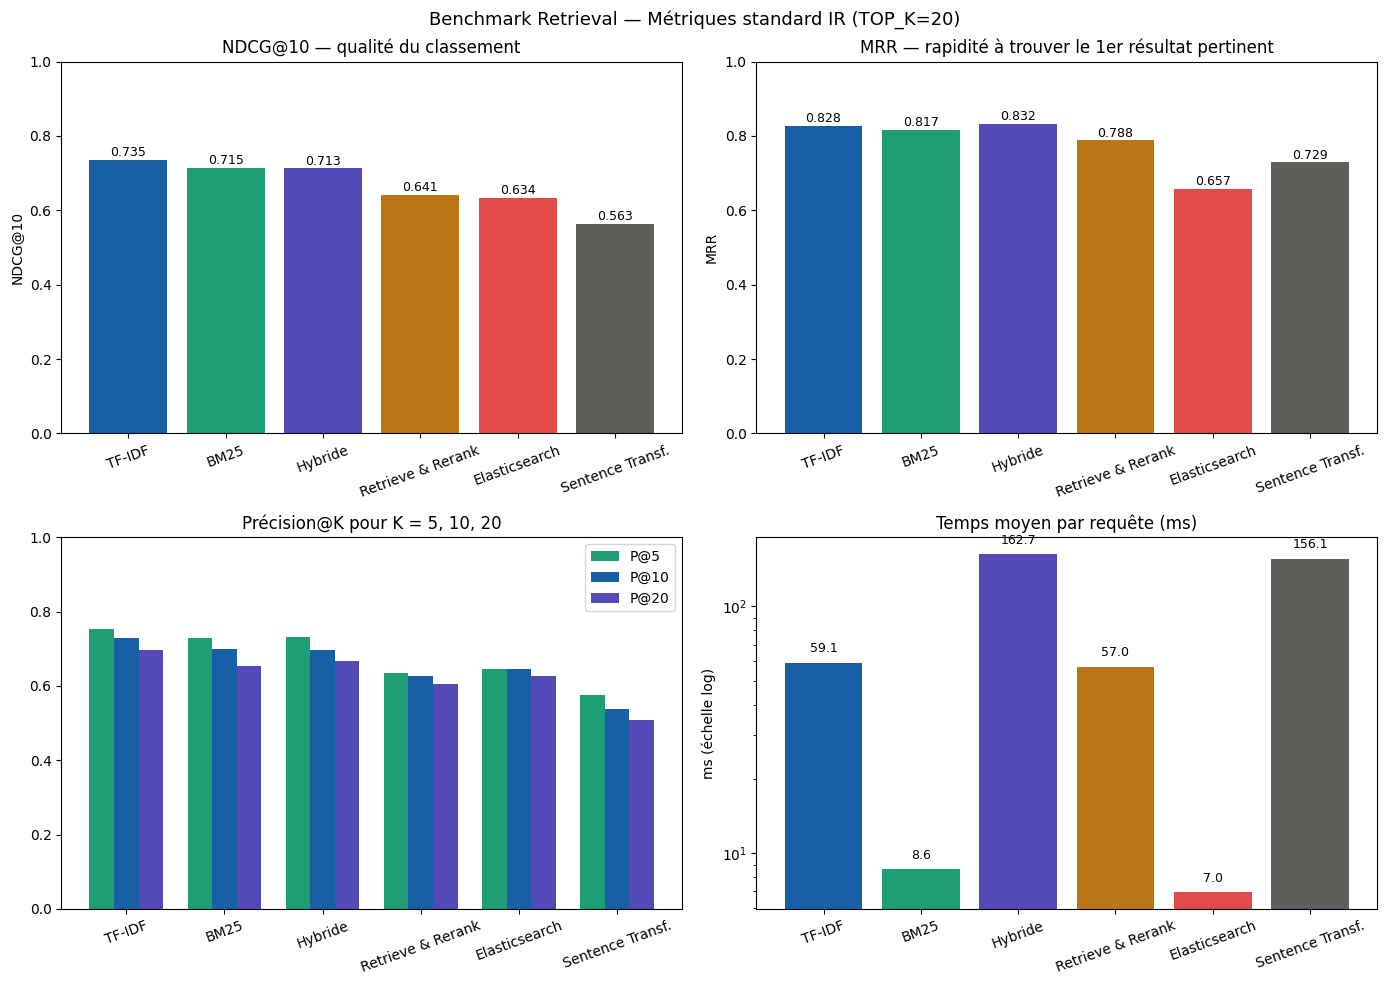

In [10]:
# ─────────────────────────────────────────────────────────────
# CELLULE 9 — Visualisations
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f"Benchmark Retrieval — Métriques standard IR (TOP_K={TOP_K})",
    fontsize=13
)

moteurs  = resume.index.tolist()
couleurs = ["#185FA5", "#1D9E75", "#534AB7", "#BA7517", "#E24B4A", "#5F5E5A"]

# ── NDCG@10 par moteur ────────────────────────────────────────
axes[0, 0].bar(moteurs, resume["NDCG@10"], color=couleurs)
axes[0, 0].set_title("NDCG@10 — qualité du classement")
axes[0, 0].set_ylabel("NDCG@10")
axes[0, 0].set_ylim(0, 1)
axes[0, 0].tick_params(axis="x", rotation=20)
for i, v in enumerate(resume["NDCG@10"]):
    axes[0, 0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

# ── MRR par moteur ────────────────────────────────────────────
axes[0, 1].bar(moteurs, resume["MRR"], color=couleurs)
axes[0, 1].set_title("MRR — rapidité à trouver le 1er résultat pertinent")
axes[0, 1].set_ylabel("MRR")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].tick_params(axis="x", rotation=20)
for i, v in enumerate(resume["MRR"]):
    axes[0, 1].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

# ── Précision@K pour différents K ────────────────────────────
x = np.arange(len(moteurs))
w = 0.25
axes[1, 0].bar(x - w, resume["P@5"],  w, label="P@5",  color="#1D9E75")
axes[1, 0].bar(x,     resume["P@10"], w, label="P@10", color="#185FA5")
axes[1, 0].bar(x + w, resume["P@20"], w, label="P@20", color="#534AB7")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(moteurs, rotation=20)
axes[1, 0].set_title("Précision@K pour K = 5, 10, 20")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()

# ── Temps d'exécution (log) ───────────────────────────────────
axes[1, 1].bar(moteurs, resume["Temps(ms)"], color=couleurs)
axes[1, 1].set_title("Temps moyen par requête (ms)")
axes[1, 1].set_ylabel("ms (échelle log)")
axes[1, 1].set_yscale("log")
axes[1, 1].tick_params(axis="x", rotation=20)
for i, v in enumerate(resume["Temps(ms)"]):
    axes[1, 1].text(i, v * 1.1, f"{v:.1f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("benchmark_definitif.png", dpi=150, bbox_inches="tight")
plt.show()

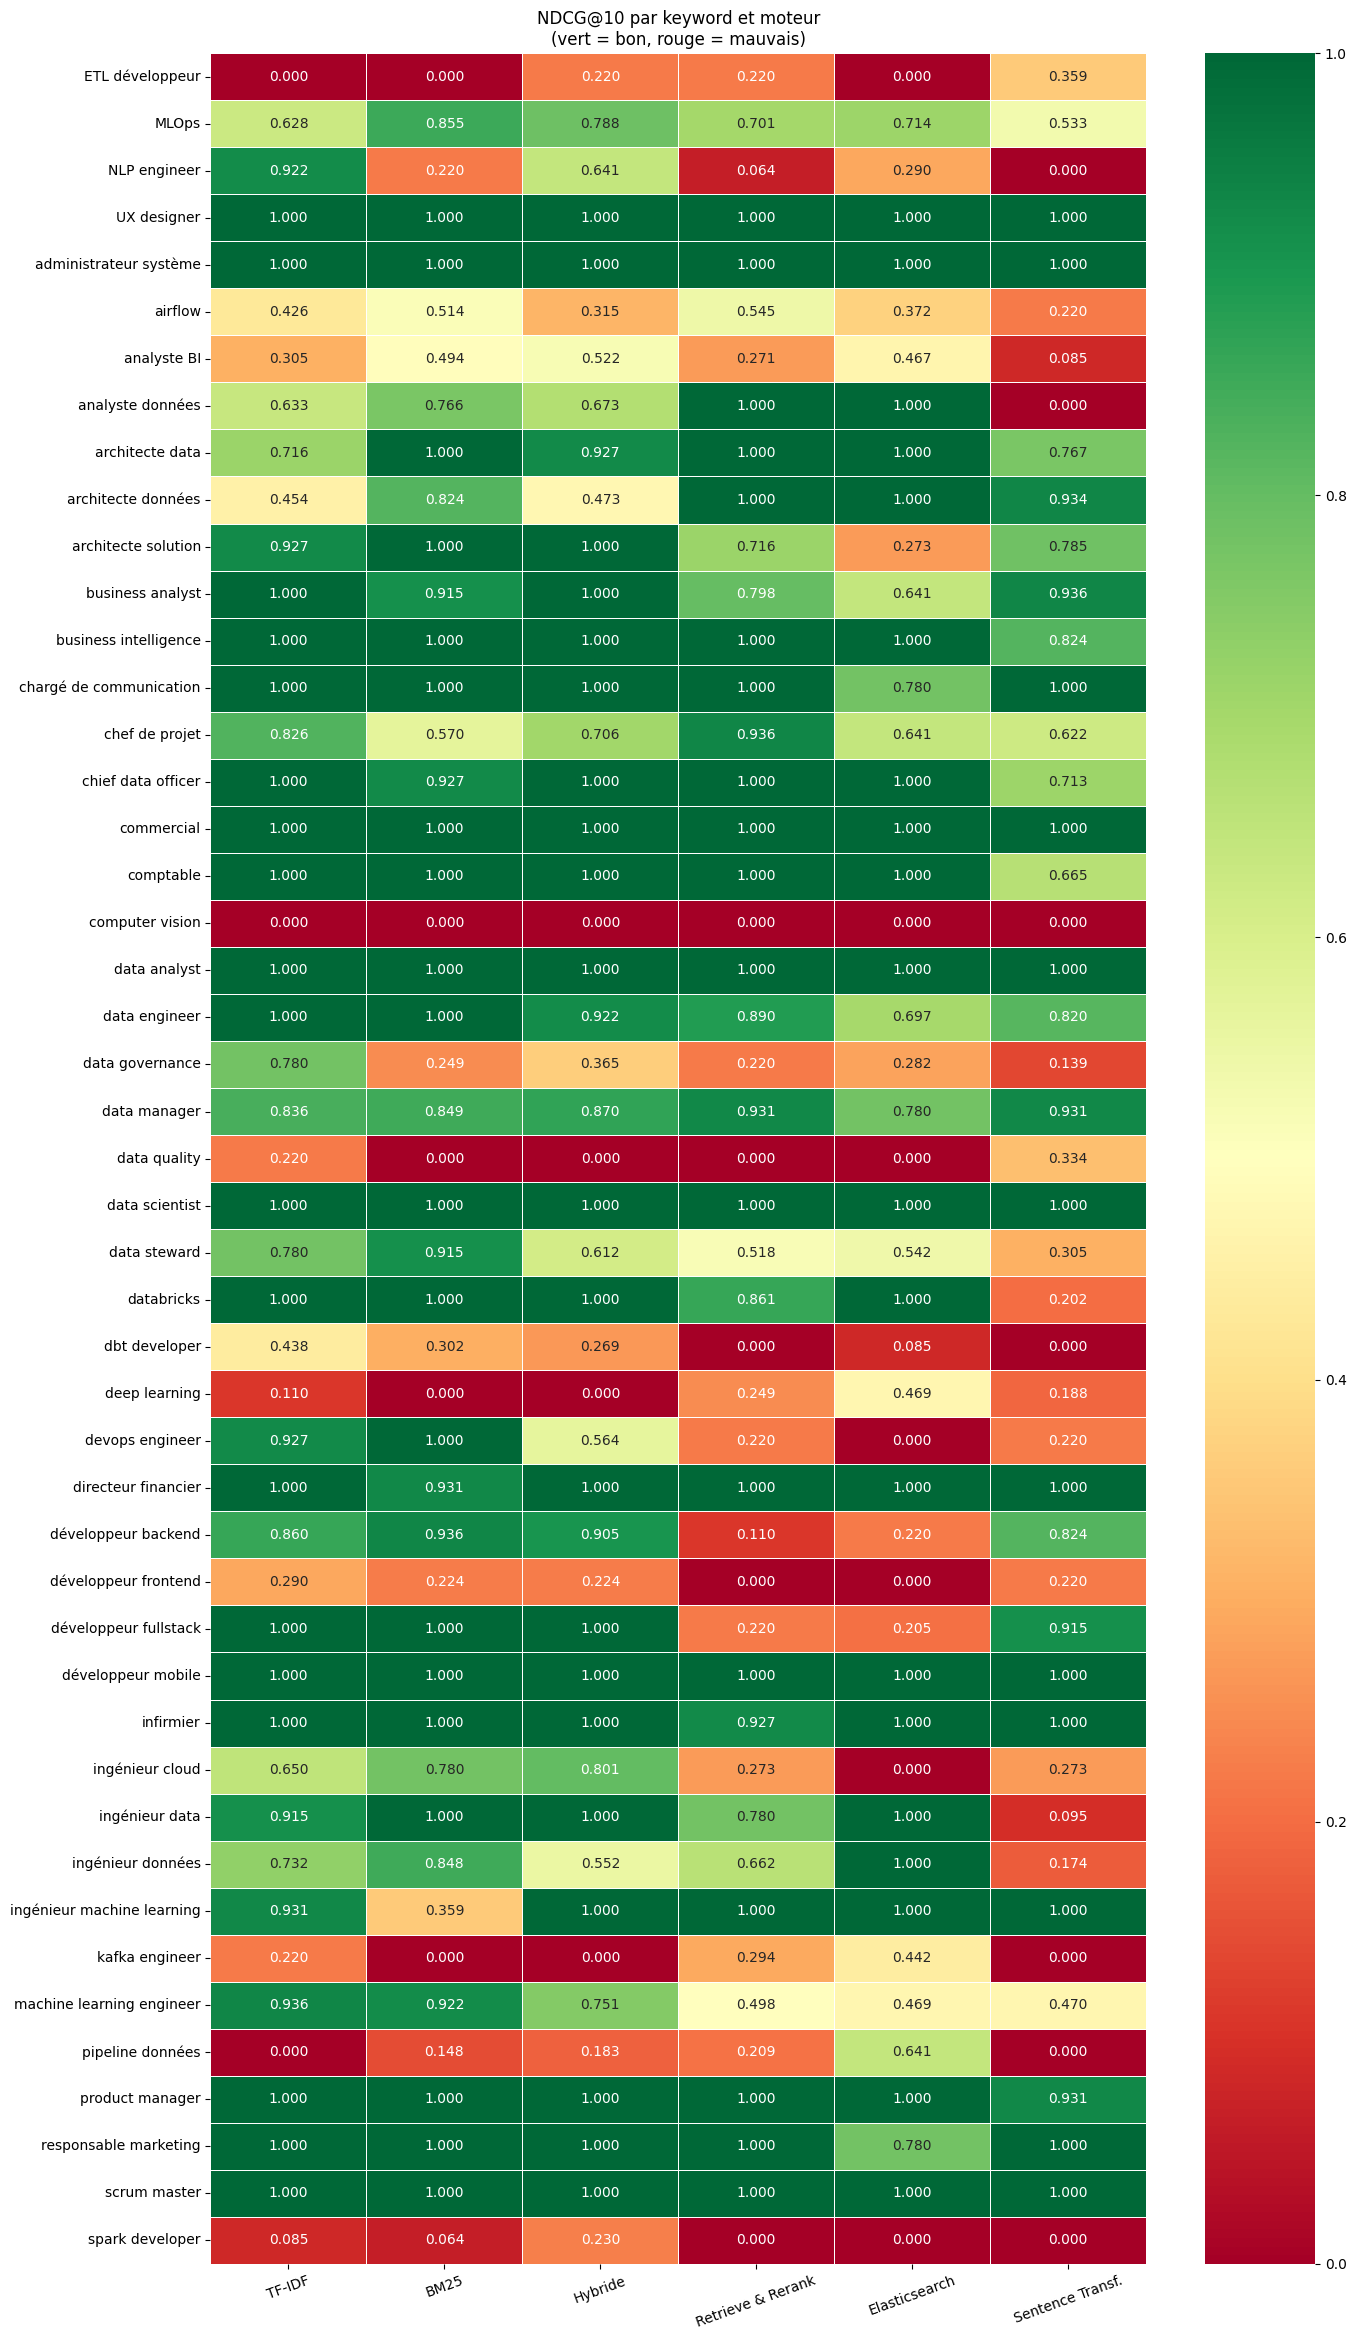

In [11]:
# ─────────────────────────────────────────────────────────────
# CELLULE 10 — Analyse par keyword
# ─────────────────────────────────────────────────────────────

# Heatmap NDCG@10 par keyword et moteur
df_pivot = df_resultats.pivot_table(
    index   = "keyword",
    columns = "moteur",
    values  = "ndcg@10",
).round(3)

# Trier les colonnes par performance décroissante
ordre_colonnes = df_pivot.mean().sort_values(ascending=False).index
df_pivot       = df_pivot[ordre_colonnes]

fig, ax = plt.subplots(figsize=(14, max(6, len(keywords) * 0.5)))
sns.heatmap(
    df_pivot,
    annot  = True,
    fmt    = ".3f",
    cmap   = "RdYlGn",
    vmin   = 0,
    vmax   = 1,
    ax     = ax,
    linewidths = 0.5,
)
ax.set_title("NDCG@10 par keyword et moteur\n(vert = bon, rouge = mauvais)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("heatmap_ndcg_keyword.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# ─────────────────────────────────────────────────────────────
# CELLULE 11 — Conclusion automatique
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("  CONCLUSION")
print("=" * 60)

for moteur in resume.index:
    print(f"\n{moteur}")
    print(f"  NDCG@10  : {resume.loc[moteur, 'NDCG@10']:.4f}")
    print(f"  MRR      : {resume.loc[moteur, 'MRR']:.4f}")
    print(f"  P@10     : {resume.loc[moteur, 'P@10']:.4f}")
    print(f"  Temps    : {resume.loc[moteur, 'Temps(ms)']:.2f} ms")

# Meilleur sur chaque métrique
print(f"\n→ Meilleur NDCG@10 : {resume['NDCG@10'].idxmax()}")
print(f"→ Meilleur MRR     : {resume['MRR'].idxmax()}")
print(f"→ Meilleur P@10    : {resume['P@10'].idxmax()}")
print(f"→ Plus rapide      : {resume['Temps(ms)'].idxmin()}")

# Score composite
resume["score_composite"] = (
    resume["NDCG@10"] * 0.40 +
    resume["MRR"]     * 0.30 +
    resume["P@10"]    * 0.30
).round(4)

print(f"\n→ Meilleur score composite (NDCG×0.4 + MRR×0.3 + P@10×0.3) :")
print(f"  {resume['score_composite'].idxmax()} "
      f"({resume['score_composite'].max():.4f})")

print("""
─────────────────────────────────────────────────────────────
INTERPRÉTATION
─────────────────────────────────────────────────────────────
NDCG@10  → les résultats pertinents apparaissent-ils en tête ?
MRR      → le premier résultat pertinent est-il rapidement trouvé ?
P@10     → sur 10 résultats, combien sont pertinents ?

Ces métriques reflètent l'expérience réelle d'un utilisateur
qui ne regarde que les premiers résultats.
─────────────────────────────────────────────────────────────
""")

conn.close()
print("Connexions fermées.")

  CONCLUSION

TF-IDF
  NDCG@10  : 0.7351
  MRR      : 0.8281
  P@10     : 0.7298
  Temps    : 59.13 ms

BM25
  NDCG@10  : 0.7151
  MRR      : 0.8167
  P@10     : 0.7000
  Temps    : 8.63 ms

Hybride
  NDCG@10  : 0.7130
  MRR      : 0.8317
  P@10     : 0.6979
  Temps    : 162.75 ms

Retrieve & Rerank
  NDCG@10  : 0.6406
  MRR      : 0.7883
  P@10     : 0.6255
  Temps    : 57.00 ms

Elasticsearch
  NDCG@10  : 0.6338
  MRR      : 0.6572
  P@10     : 0.6468
  Temps    : 6.96 ms

Sentence Transf.
  NDCG@10  : 0.5634
  MRR      : 0.7289
  P@10     : 0.5383
  Temps    : 156.13 ms

→ Meilleur NDCG@10 : TF-IDF
→ Meilleur MRR     : Hybride
→ Meilleur P@10    : TF-IDF
→ Plus rapide      : Elasticsearch

→ Meilleur score composite (NDCG×0.4 + MRR×0.3 + P@10×0.3) :
  TF-IDF (0.7614)

─────────────────────────────────────────────────────────────
INTERPRÉTATION
─────────────────────────────────────────────────────────────
NDCG@10  → les résultats pertinents apparaissent-ils en tête ?
MRR      → le pr